# **Bank Fraud Detection** 

This project focuses on detecting fraudulent financial transactions using a large-scale dataset containing over **6.3 million transaction records**. The objective is to build a machine learning model that can accurately identify fraudulent transactions and help financial institutions reduce losses caused by fraud.

#### **Dataset Information:** 
The dataset contains the records of financial transactions for fraud detection. (6.3 Million Records)

**Columns:**

1. step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 
   (30 days simulation).
2. type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
3. amount - amount of the transaction in local currency.
4. nameOrig - customer who started the transaction
5. oldbalanceOrg - initial balance before the transaction
6. newbalanceOrig - new balance after the transaction
7. nameDest - customer who is the recipient of the transaction
8. oldbalanceDest - initial balance recipient before the transaction. Note that there is not 
   information for customers that start with M (Merchants).
9. newbalanceDest - new balance recipient after the transaction. Note that there is not information for 
   customers that start with M (Merchants).
10. isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this 
    specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.
11. isFlaggedFraud - The business model aims to control massive transfers from one account to another 
    and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

**LINK**: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset?resource=download

## Import Libraries & Configuration

In [1]:
# Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer


# Configuration
sns.set_style('darkgrid')
plt.rcParams["figure.figsize"] = (6, 4)

## Load Dataset

In [85]:
# Load the dataset 
df = pd.read_csv('../data/fraud_data.csv')

## Exploratory Data Analysis (EDA)

In [3]:
# Check sample dataset 
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Check shape of the dataset 
print(f"Number of Rows: {df.shape[0]}")    
print(f"Number of Columns: {df.shape[1]}")    

Number of Rows: 6362620
Number of Columns: 11


In [5]:
# Check info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
# Check statistical summary 
df.describe().astype(int).T

,count,mean,std,min,25%,50%,75%,max
step,6362620,243,142,1,156,239,335,743
amount,6362620,179861,603858,0,13389,74871,208721,92445516
oldbalanceOrg,6362620,833883,2888242,0,0,14208,107315,59585040
newbalanceOrig,6362620,855113,2924048,0,0,0,144258,49585040
oldbalanceDest,6362620,1100701,3399180,0,0,132705,943036,356015889
newbalanceDest,6362620,1224996,3674128,0,0,214661,1111909,356179278
isFraud,6362620,0,0,0,0,0,0,1
isFlaggedFraud,6362620,0,0,0,0,0,0,1


In [7]:
# Check missing values 
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
# Check duplicate values 
df.duplicated().sum()

np.int64(0)

In [9]:
# Check type, isFraud and isFlaggedFraud total values 

print(df['type'].value_counts())
print("-"*40)
print(df['isFraud'].value_counts())
print("-"*40)
print(df['isFlaggedFraud'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
----------------------------------------
isFraud
0    6354407
1       8213
Name: count, dtype: int64
----------------------------------------
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [11]:
# Check fraud ratio
print(f"Non-Fraud Ratio: {round(df['isFraud'].value_counts(normalize=True)[0]*100,4)}%")
print(f"Fraud Ratio: {round(df['isFraud'].value_counts(normalize=True)[1]*100,4)}%")

Non-Fraud Ratio: 99.8709%
Fraud Ratio: 0.1291%


In [39]:
# Check flagged fraud ratio
print(f"Flagged Fraud Ratio: {round(df['isFlaggedFraud'].value_counts(normalize=True)[1]*100,4)}%")

Flagged Fraud Ratio: 0.0003%


#### Observation: 
- The dataset contains **6362620 Rows** and **11 Columns** .
- There is no any missing and duplicate value in this dataset.
- Total transactions: **6362620**
- Total normal transactions: **6354407**
- Total fraud transactions: **8213** 
- Overall fraud transactions rate:  0.1291%
- Overall flagged fraud transactions rate: 0.0003%
- The dataset is highly imbalanced.
- Balance-related features (**oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest**) contain many zero values. 
- There is skewness in some columns refers to outliers.

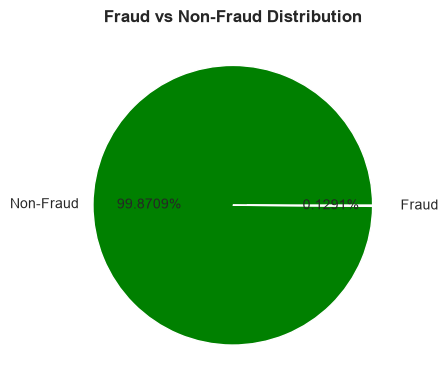

In [12]:
# Fraud vs Non_Fraud Distribution 
fraud_ratio = round(df['isFraud'].value_counts(normalize=True)*100,4)

plt.pie(fraud_ratio,labels=['Non-Fraud','Fraud'],colors=['green', 'red'],autopct='%1.4f%%',explode=(0,0.10))
plt.title('Fraud vs Non-Fraud Distribution', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

While approximately **0.13%** Of transactions are truly fraudulent, the existing rule based system flags less than **0.001%** of transactions, including that most frudulent activity goes **undetected**.

type
CASH_OUT    35.17
PAYMENT     33.81
CASH_IN     21.99
TRANSFER     8.38
DEBIT        0.65
Name: proportion, dtype: float64


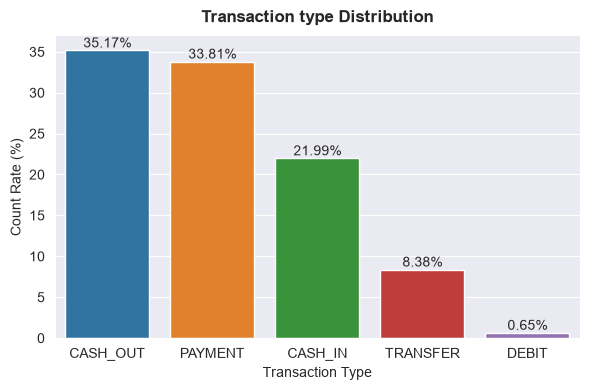

In [13]:
# Check transaction type percentage 
type_percentage = round(df['type'].value_counts(normalize=True)*100,2)
print(type_percentage)

ax = sns.barplot(x=type_percentage.index,y=type_percentage.values,palette='tab10')

plt.title('Transaction type Distribution',fontweight='bold',pad=10)
plt.xlabel('Transaction Type')
plt.ylabel('Count Rate (%)')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')
    
sns.despine() 
plt.tight_layout()
plt.show()

type
TRANSFER    0.77
CASH_OUT    0.18
CASH_IN     0.00
DEBIT       0.00
PAYMENT     0.00
Name: isFraud, dtype: float64


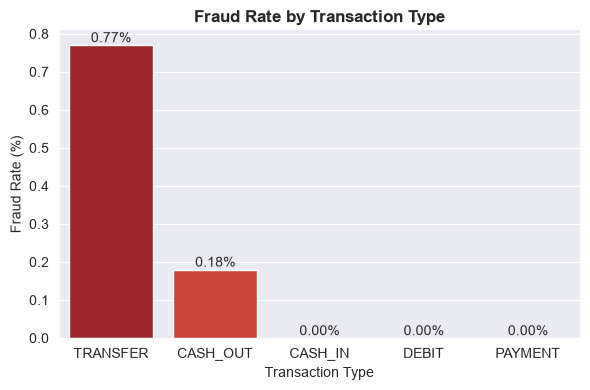

In [14]:
# Check fraud rate by transaction type 
fraud_by_type = round(df.groupby('type')['isFraud'].mean().sort_values(ascending=False)*100,2)
print(fraud_by_type)

ax = sns.barplot( x=fraud_by_type.index,y=fraud_by_type.values,palette='Reds_r')

plt.title('Fraud Rate by Transaction Type', fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')

sns.despine()
plt.tight_layout()
plt.show()



#### Observation: 
- This dataset is dominated by **CASH_OUT, PAYMENT, and CASH_IN**
- Fraud occurs only in **TRANSFER** and **CASH_OUT** type of transactions. 
- **TRANSFER** has the highest fraud rate - **(77%)**
- **CASH_OUT** has lower fraud rate - **(18%)**
- **PAYMENT**, **CASH_IN**, and **DEBIT** have 0 fraudulent transactions.
- From this insight it looking like **Fraudsters first transfer money to another account and then cash it out**. This aligns with the dataset description.

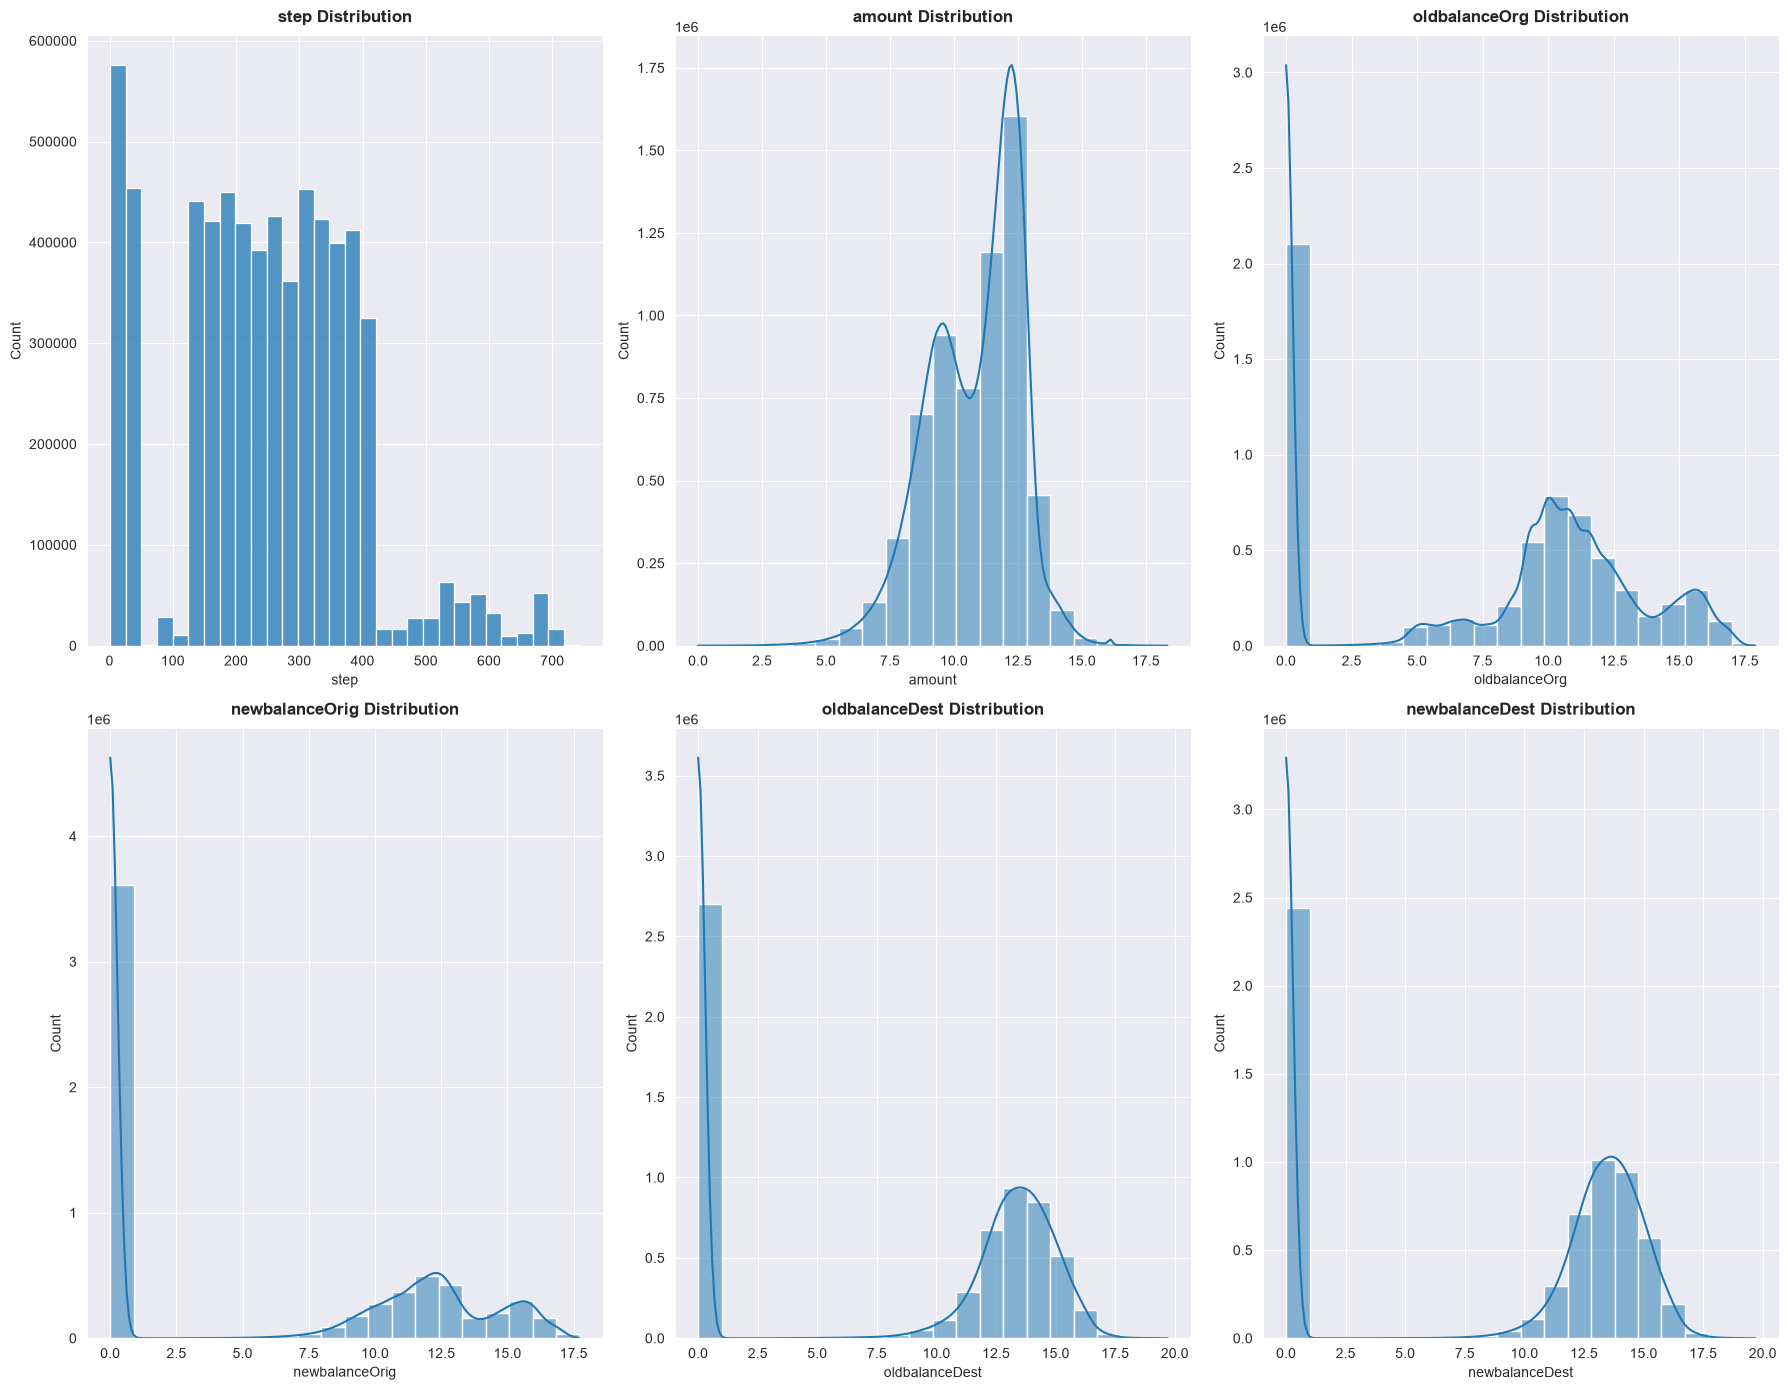

In [ ]:
# Check numerical columns distribution
numerical_columns = ['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

plt.figure(figsize=(12, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)

    if col=='step': 
        sns.histplot(data=df,x=col,bins=30)
    else: 
        sns.histplot(np.log1p(df[col]),bins=20,kde=True)

    plt.title(f'{col} Distribution', fontweight='bold', pad=10)
    plt.xlabel(col)
    plt.ylabel('Count')
    sns.despine()

plt.tight_layout()
plt.show()

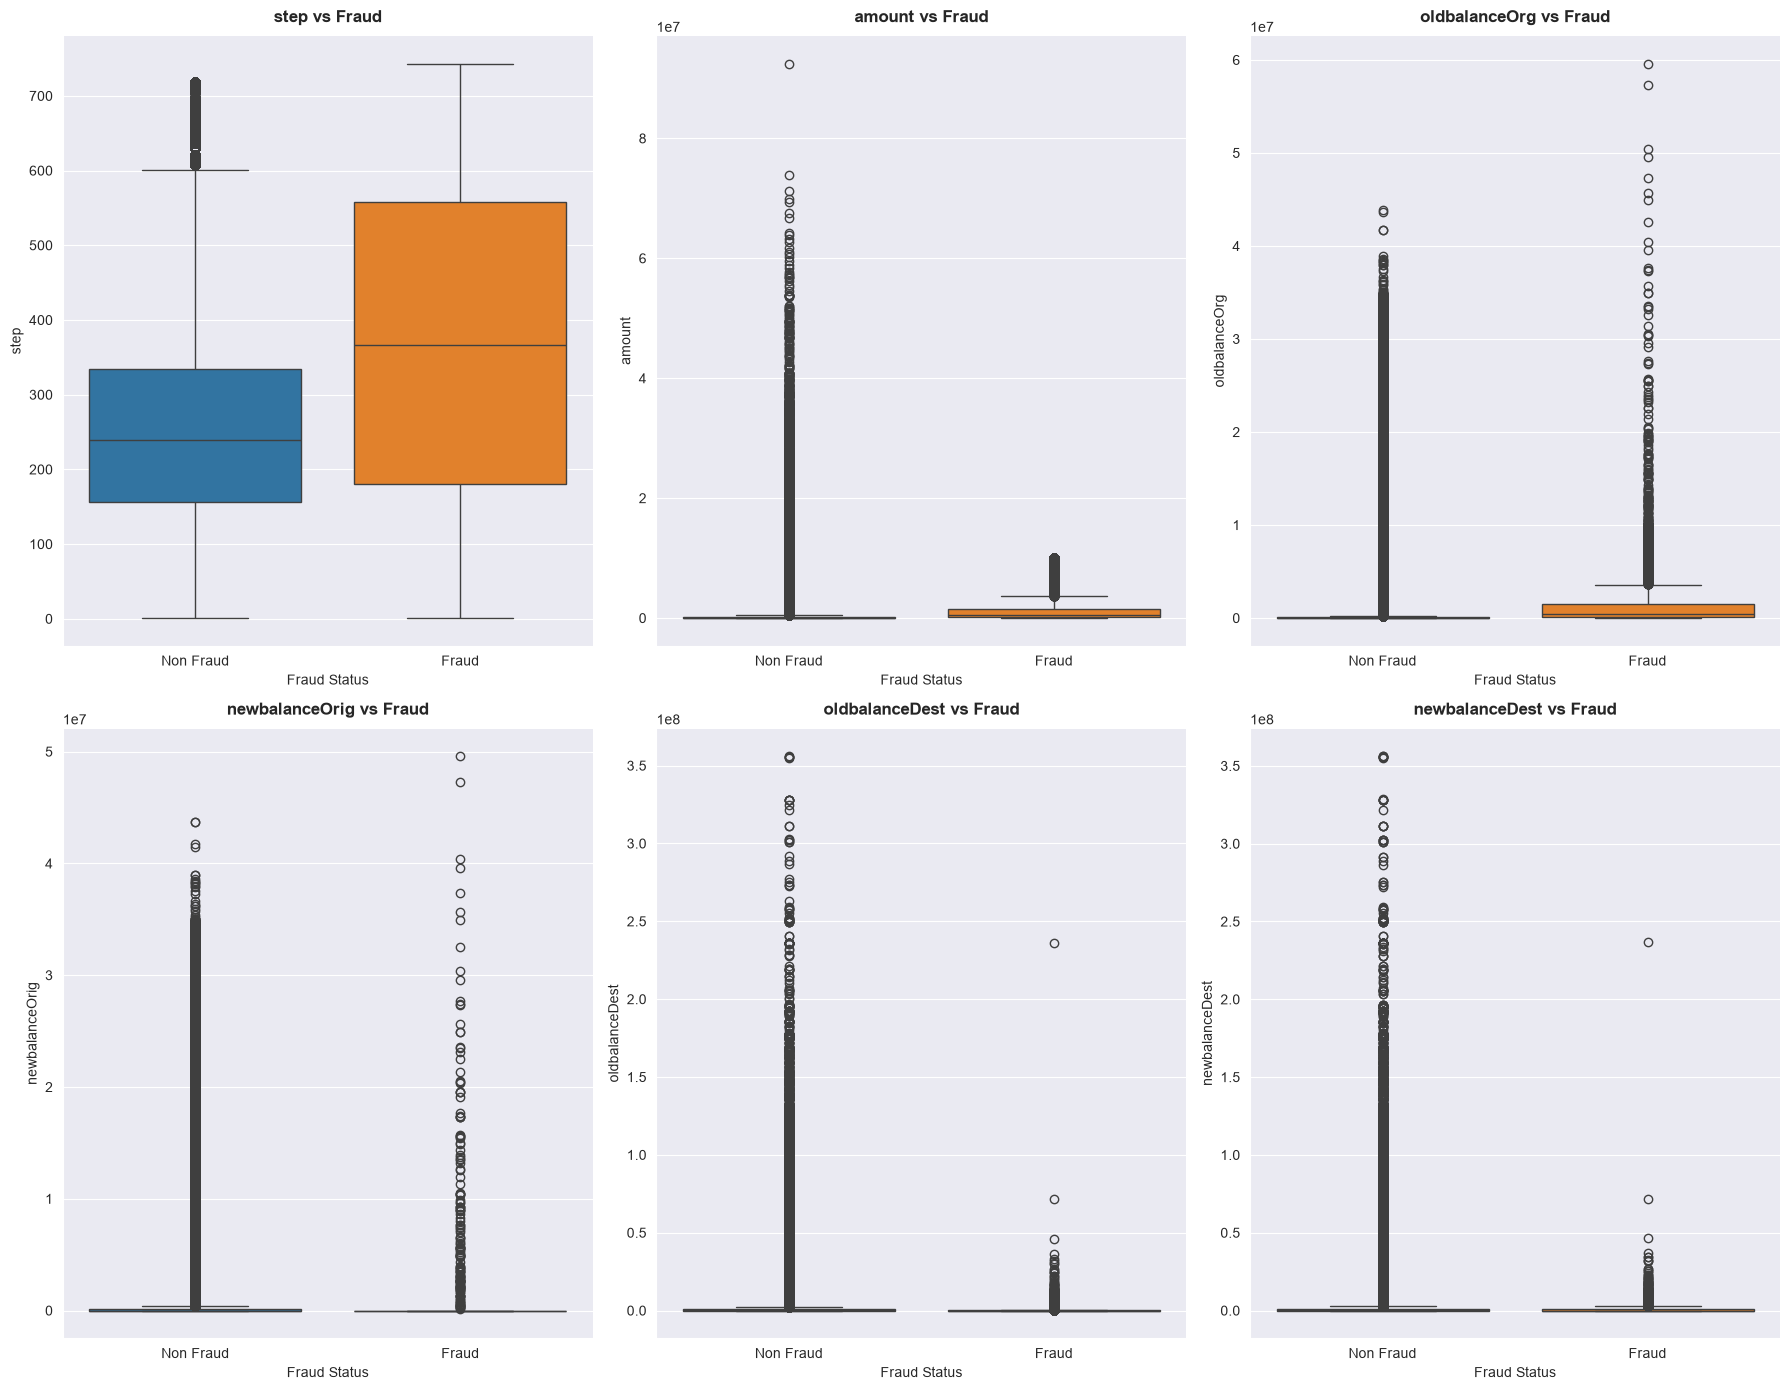

In [ ]:
plt.figure(figsize=(12,10))

for i,col in enumerate(numerical_columns,1):
    plt.subplot(2,3,i)

    sns.boxplot(
        data=df,
        x='isFraud',
        y=col,
        palette='tab10'
    )

    plt.title(f'{col} vs Fraud', fontweight='bold', pad=10)
    plt.xlabel('Fraud Status')
    plt.ylabel(col)
    plt.xticks([0,1],['Non Fraud','Fraud'])
    sns.despine()

plt.tight_layout()
plt.show()

In [47]:
# Create a new DataFrame for step(time) analysis 
time_df = pd.DataFrame()

time_df[['step','isFraud']] = df[['step','isFraud']]

time_df['hour'] = time_df['step'] % 24

hourly_stats = time_df.groupby('hour').agg(
    total_transactions = ('isFraud','count'),
    fraud_transactions = ('isFraud','sum'),
    fraud_rate = ('isFraud','mean')
).reset_index()

hourly_stats.head()

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


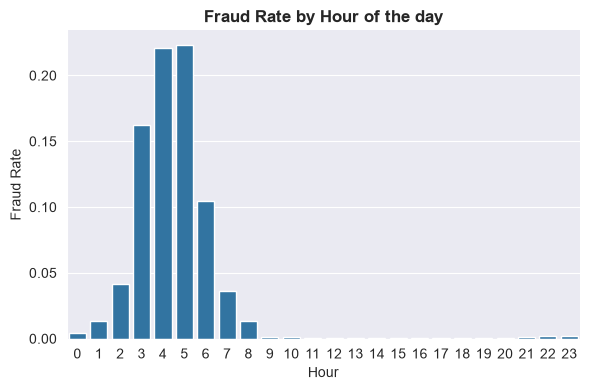

In [50]:
# Check fraud rate by hour 
sns.barplot(data=hourly_stats,x='hour',y='fraud_rate')
plt.title('Fraud Rate by Hour of the day', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
sns.despine()
plt.tight_layout()
plt.show()

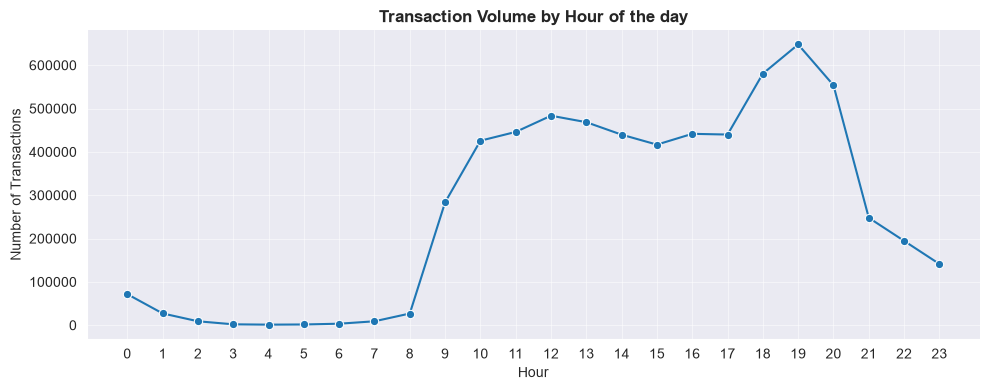

In [63]:
# Check transaction by hour 
plt.figure(figsize=(10,4))
sns.lineplot(data=hourly_stats,x='hour',y='total_transactions',marker='o')
plt.title('Transaction Volume by Hour of the day', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

In [74]:
# Create is_night to analyse day vs night  
time_df['is_night'] = time_df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
day_night_fraud = (time_df[time_df['isFraud']==1]['is_night'].value_counts(normalize=True).rename({0:'Day',1:'Night'}))
day_night_fraud

is_night
Day      0.674906
Night    0.325094
Name: proportion, dtype: float64

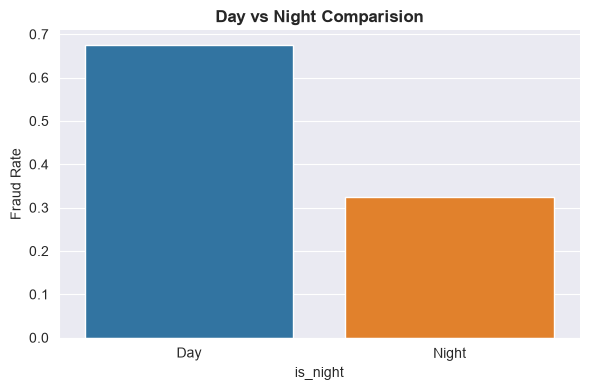

In [78]:
# Check Dya vs Night Comparison 
sns.barplot(x=day_night_fraud.index,y=day_night_fraud.values,palette='tab10')
plt.title('Day vs Night Comparision',fontweight='bold')
plt.ylabel('Fraud Rate')
sns.despine()
plt.tight_layout()
plt.show()

In [18]:
# Check top 10 senders customers
top_senders = df[['nameOrig','amount']].sort_values(by='amount',ascending=False).head(10)
top_senders

,nameOrig,amount
3686583,C1715283297,92445516.64
4060598,C2127282686,73823490.36
4146397,C2044643633,71172480.42
3946920,C1425667947,69886731.30
3911956,C1584456031,69337316.27
3937152,C811810230,67500761.29
4105338,C420748282,66761272.21
3892529,C1139847449,64234448.19
3991638,C300140823,63847992.58
4143801,C372535854,63294839.63


In [19]:
# Check top 10 receiver customers 
top_receivers = df[['nameDest','amount']].sort_values(by='amount',ascending=False).head(10)
top_receivers

,nameDest,amount
3686583,C439737079,92445516.64
4060598,C753026640,73823490.36
4146397,C84111522,71172480.42
3946920,C167875008,69886731.30
3911956,C1472140329,69337316.27
3937152,C1757599079,67500761.29
4105338,C1073241084,66761272.21
3892529,C65111466,64234448.19
3991638,C514940761,63847992.58
4143801,C1871605747,63294839.63


In [20]:
# Check sender customers who involved in fraud 
fraud_senders =  df[df['isFraud']==1]['nameOrig'].value_counts().head(10)
fraud_senders

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [21]:
# Check receiver customers who involved in fraud 
fraud_receiver =  df[df['isFraud']==1]['nameDest'].value_counts().head(10)
fraud_receiver

nameDest
C410033330     2
C803116137     2
C904300960     2
C1013511446    2
C2020337583    2
C200064275     2
C185805228     2
C52390890      2
C935310781     2
C1827219533    2
Name: count, dtype: int64

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64


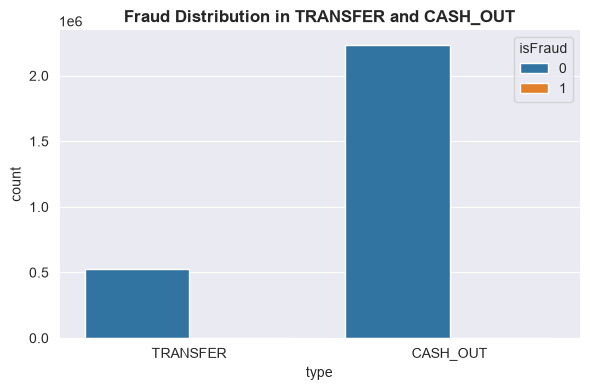

In [22]:
#Check fraud distribution in TRANSFER and CASH_OUT
farud_transaction_type = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
print(farud_transaction_type['type'].value_counts())

sns.countplot(data=farud_transaction_type,x='type',hue='isFraud')
plt.title('Fraud Distribution in TRANSFER and CASH_OUT', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

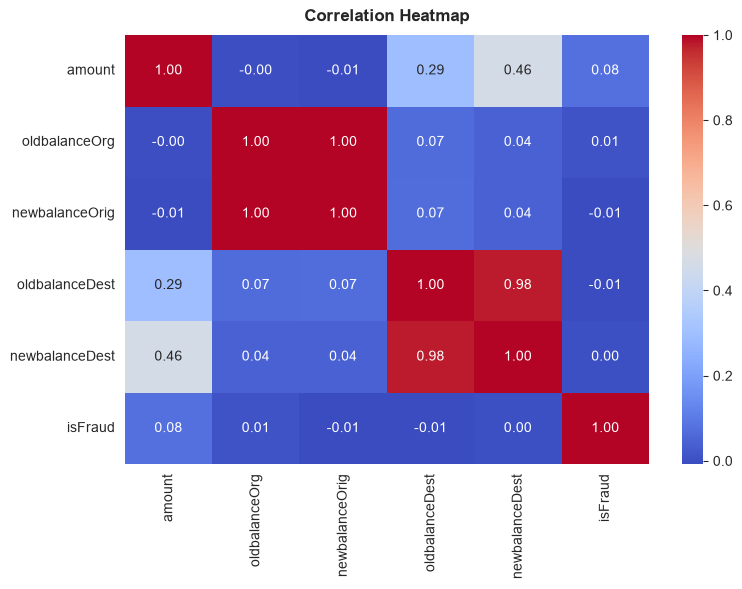

In [81]:
# Check correlations 
plt.figure(figsize=(8,6))
corr_columns = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest','isFraud']]
sns.heatmap(corr_columns.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

#### Observation: 
This corellation matrix reveals severe multicollinearity between pre-transaction and post-transaction balances, indicating redundancy. To address this balance-difference features were engineered and
redundent variables need to be removed, improving model stability and interpretability.

In [86]:
# Make copy of the dataset 
df_copy = df.copy()
df_copy.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Feature Engineering 

In [24]:
# Change in sender account balance
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# Change in receiver's account balance
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [35]:
# Drop unnecessary columns 
final_df = df.drop(['step','nameOrig','nameDest','isFlaggedFraud'],axis=1)
final_df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [26]:
# Define Numerical, Categorical and Target Columns

# Target column
target_column = 'isFraud'

# Numerical_columns 
numerical_columns = [col for col  in final_df.select_dtypes(include=['int64','float64']).columns if col!= target_column]

# Categorical_columns
categorical_columns = final_df.select_dtypes(include=['object']).columns.to_list()

print("Target Column:")
print(target_column)

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Target Column:
isFraud

Numerical Columns:
['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest']

Categorical Columns:
['type']


In [27]:
# Separating dependent and independent features 
X = final_df.drop(target_column,axis=1)
y = final_df[target_column]

In [28]:
# Check X 
X.head()


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.0


In [29]:
# Check y 
y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

## Train Test Split 

In [30]:
# train test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,stratify=y)

In [31]:
# Check train shape and test shape 
print(f"Train shape : {X_train.shape}")
print(f"Test shape : {X_test.shape}")

Train shape : (4453834, 8)
Test shape : (1908786, 8)


## Data Preprocessing

#### Build Preprocessing Pipeline

In [32]:
# Numerical pipeline 
numerical_preprocessing = Pipeline([
    ('scaler',StandardScaler())
])

# Categorical pipeline 
categorical_preprocessing = Pipeline([
    ('ohe',OneHotEncoder(drop='first'))
])

#### Build ColumnTransformer

In [33]:
# Column Transformer 
preprocessor = ColumnTransformer([
    ('num',numerical_preprocessing,numerical_columns),
    ('cat',categorical_preprocessing,categorical_columns)
])

## Model Training & Evaluation